# Maxwell

In [ ]:
import csv
import tempfile
import time
from operator import attrgetter
from pathlib import Path

import ansys.aedt.core
import matplotlib.pyplot as plt
import numpy as np
# from ansys.aedt.core.examples.downloads import download_file
AEDT_VERSION = "2026.1"
NUM_CORES = 4
NG_MODE = False  # Open AEDT UI when it is launched.
project_name="D:/KDH/e10_26R1mot_ANSYSEM_2D.aedt"

## ref Model

In [ ]:
# project_name = Path(temp_folder.name) / "PM_Motor.aedt"\


m2d = ansys.aedt.core.Maxwell2d(
    project=project_name,
    version=AEDT_VERSION,
    design="Motor-CAD e10_26R1mot",
    solution_type="TransientXY",
    new_desktop=False,
    non_graphical=NG_MODE,
)
m2d.modeler.model_units = "mm"  # Specify model units

In [ ]:
# import sys
# import os
# import importlib

# # eMach/pyAEDT 모듈 경로 추가
# py_aedt_path = os.path.abspath("D:/KDH/새 폴더/EveryMotor/eMach/pyAEDT")
# if py_aedt_path not in sys.path:
#     sys.path.append(py_aedt_path)

# # Jupyter Notebook 환경에서는 모듈이 캐싱되므로 추가된 함수를 인식하려면 reload가 필요합니다.
# import aedt_report_utils
# importlib.reload(aedt_report_utils)
# from aedt_report_utils import get_available_categories, print_expressions_in_category, find_expressions


In [ ]:
# m2dPost=m2d.post
# # 1. 사용 가능한 카테고리(범주) 확인
# categories = get_available_categories(m2dPost)
# print("Available Categories:", categories)

# # 2. 'Loss' 하위의 항목 중에서 "PerWindingSolidLoss" 혹은 "WG_Ph1"이 포함된 것만 추출
# # 반환되는 리스트는 get_solution_data에 직접 전달 가능한 형태입니다.
# target_expressions = find_expressions(m2dPost, category="Loss", search_keyword="PerWindingSolidLoss")
# print("\nFiltered Expressions:", target_expressions)

In [ ]:
# # 앞에서 찾은 리스트(target_expressions)를 리스트 그대로 expressions 인자에 넘겨줍니다. 
# if target_expressions:
#     solutions = m2d.post.get_solution_data(
#         expressions=target_expressions, # "PerWindingSolidLoss(WG_Ph1_P1)" 혹은 추출된 여러 값이 동시에 들어감
#         setup_sweep_name=m2d.nominal_sweep,
#         primary_sweep_variable="Time",
#         domain="Sweep",
#     )
    
#     # 추출한 데이터가 유효한지 데이터 라벨 확인 (옵션)
#     if solutions:
#         print("Successfully obtained solutions for:", solutions.expressions)
# else:
#     print("No target expressions matched the filter.")

In [ ]:
oDesign=m2d.odesktop.GetActiveProject().GetActiveDesign()
oModule = oDesign.GetModule("ReportSetup")
ReportNames=oDesign.GetModule("ReportSetup").GetAllReportNames()

In [ ]:
# 결과를 CSV로 즉시 덤프 (COM 없이 내부 메모리 직접 접근)
oModule.ExportToFile(ReportNames[-1], r"D:/KDH/loss_export_refMQS.csv")
import pandas as pd
dfref = pd.read_csv(r"D:/KDH/loss_export_refMQS.csv")
target_expressions = dfref.columns[1:].tolist() # 첫 번째 열은 시간 데이터이므로 제외하고 나머지 열이 표현식 이름이 됩니다.
totalTimeStep = len(dfref[dfref.columns[0]])  # 시간 데이터의 길이
time_data = dfref[dfref.columns[0]].values  # 시간 데이터
avg_loss_ref = {}
for expr in target_expressions:
    loss_data = dfref[expr].values  # 손실 데이터
    SingleCycleTimeStep=int(totalTimeStep/2)
    time_data_single_cycle = time_data[-SingleCycleTimeStep:]
    loss_data_single_cycle = loss_data[-SingleCycleTimeStep:]
    plt.plot(time_data_single_cycle, loss_data_single_cycle, label=expr)
    plt.legend()
    plt.xlabel('Time (ms)')
    plt.ylabel(f'Loss (kW)')
    plt.title('Loss vs Time for the Last Cycle (Scaled Design)')

    avg_loss_ref[expr] = float(np.mean(loss_data_single_cycle))
    plt.axhline(y=avg_loss_ref[expr], color='r', linestyle='--', label=f'Average Loss: {avg_loss_ref[expr]:.4f} kW')
    plt.legend()
    
total_windingLoss_ref= sum( avg_loss_ref[expr] for expr in target_expressions)
print(f"Total Winding Loss: {total_windingLoss_ref:.4f} kW")

In [ ]:
avg_loss = {}
for expr in target_expressions: 
# AEDT와 통신하지 않고, 이미 캐싱된 메모리에서 행렬 필터링으로만 바로 가져옵니다.
    time_data, loss_data = solutions.get_expression_data(expression=expr, formula="real")
    if solutions.units_sweeps["Time"] == "ms":
        time_data = np.array(time_data)  # ms -> ms
    elif solutions.units_sweeps["Time"] == "us":
        time_data = np.array(time_data)/1e3  # us -> ms
    elif solutions.units_sweeps["Time"] == "ns":
        time_data = np.array(time_data)/1e6  # ns -> ms   
    
    if solutions.units_data.get(expr, "") == "W":
        loss_data = np.array(loss_data)/1000  # W -> kW
    elif solutions.units_data.get(expr, "") == "mW":
        loss_data = np.array(loss_data)/1e6  # mW -> kW
    elif solutions.units_data.get(expr, "") == "uW":
        loss_data = np.array(loss_data)/1e9  # uW -> kW    
          
    totalTimeStep=len(time_data)
    SingleCycleTimeStep=int(totalTimeStep/2)
    time_data_single_cycle = time_data[-SingleCycleTimeStep:]
    loss_data_single_cycle = loss_data[-SingleCycleTimeStep:]
    plt.plot(time_data_single_cycle, loss_data_single_cycle, label=expr)
    plt.legend()
    plt.xlabel('Time (ms)')
    plt.ylabel(f'Loss (kW)')
    plt.title('Loss vs Time for the Last Cycle')

    avg_loss[expr] = float(np.mean(loss_data_single_cycle))
    plt.axhline(y=avg_loss[expr], color='r', linestyle='--', label=f'Average Loss: {avg_loss[expr]:.4f} kW')
    plt.legend()
    
plt.grid()
plt.show()

 
total_windingLoss= sum(avg_loss[expr] for expr in target_expressions)
print(f"Total Winding Loss: {total_windingLoss:.4f} kW")


## ScaleModel

In [ ]:
# scaled Design Loss 
SCdesign='Motor-CAD e10_26R1mot_SCModel'

# m2d.set_active_design(SCdesign)

In [ ]:
# re-open app handle on the scaled design (fresh gRPC binding)
m2d_sc = ansys.aedt.core.Maxwell2d(
    project=project_name,
    version=AEDT_VERSION,
    design=SCdesign,
    solution_type='TransientXY',
    new_desktop=False,
    non_graphical=NG_MODE,
)
setup_name_sc = list(m2d_sc.design_setups.keys())[0]
setupObj_sc = m2d_sc.get_setup(setup_name_sc)
print('fresh handle setup:', setupObj_sc.name)


In [ ]:
oDesign=m2d_sc.odesktop.GetActiveProject().GetActiveDesign()
oModule = oDesign.GetModule("ReportSetup")
ReportNames=oDesign.GetModule("ReportSetup").GetAllReportNames()

In [ ]:
# 결과를 CSV로 즉시 덤프 (COM 없이 내부 메모리 직접 접근)
oModule.ExportToFile(ReportNames[-1], r"D:/KDH/loss_export_SCLMQS.csv")
import pandas as pd
dfSCL = pd.read_csv(r"D:/KDH/loss_export_SCLMQS.csv")
target_expressions = dfSCL.columns[1:].tolist() # 첫 번째 열은 시간 데이터이므로 제외하고 나머지 열이 표현식 이름이 됩니다.
# dfSCL.plot(x=dfSCL.columns[0], y=target_expressions, kind='line') # x축은 시간 데이터, y축은 표현식 이름이 됩니다. 여러 표현식이 있을 경우 모두 라인으로 표시됩니다.

In [ ]:
totalTimeStep = len(dfSCL[dfSCL.columns[0]])  # 시간 데이터의 길이
time_data = dfSCL[dfSCL.columns[0]].values  # 시간 데이터
avg_loss_scaled = {}
for expr in target_expressions:
    loss_data = dfSCL[expr].values  # 손실 데이터
    SingleCycleTimeStep=int(totalTimeStep/2)
    time_data_single_cycle = time_data[-SingleCycleTimeStep:]
    loss_data_single_cycle = loss_data[-SingleCycleTimeStep:]
    plt.plot(time_data_single_cycle, loss_data_single_cycle, label=expr)
    plt.legend()
    plt.xlabel('Time (ms)')
    plt.ylabel(f'Loss (kW)')
    plt.title('Loss vs Time for the Last Cycle (Scaled Design)')

    avg_loss_scaled[expr] = float(np.mean(loss_data_single_cycle))
    plt.axhline(y=avg_loss_scaled[expr], color='r', linestyle='--', label=f'Average Loss: {avg_loss_scaled[expr]:.4f} kW')
    plt.legend()
total_windingLoss_SCL= sum( avg_loss_scaled[expr] for expr in target_expressions)
print(f"Total Winding Loss: {total_windingLoss_SCL:.4f} kW")

# ref vs SCL 비교 테이블


In [ ]:
print(f'Total Winding Loss (Scaled) on Maxwell: {total_windingLoss_SCL:.4f} kW')
print(f'Total Winding Loss (Reference) on Maxwell: {total_windingLoss_ref:.4f} kW')

In [ ]:
avg_loss = {}
for expr in target_expressions: 
# AEDT와 통신하지 않고, 이미 캐싱된 메모리에서 행렬 필터링으로만 바로 가져옵니다.
    time_data, loss_data = solutions.get_expression_data(expression=expr, formula="real")
    if solutions.units_sweeps["Time"] == "ms":
        time_data = np.array(time_data)  # ms -> ms
    elif solutions.units_sweeps["Time"] == "us":
        time_data = np.array(time_data)/1e3  # us -> ms
    elif solutions.units_sweeps["Time"] == "ns":
        time_data = np.array(time_data)/1e6  # ns -> ms   
    
    if solutions.units_data.get(expr, "") == "W":
        loss_data = np.array(loss_data)/1000  # W -> kW
    elif solutions.units_data.get(expr, "") == "mW":
        loss_data = np.array(loss_data)/1e6  # mW -> kW
    elif solutions.units_data.get(expr, "") == "uW":
        loss_data = np.array(loss_data)/1e9  # uW -> kW    
          
    totalTimeStep=len(time_data)
    SingleCycleTimeStep=int(totalTimeStep/2)
    time_data_single_cycle = time_data[-SingleCycleTimeStep:]
    loss_data_single_cycle = loss_data[-SingleCycleTimeStep:]
    plt.plot(time_data_single_cycle, loss_data_single_cycle, label=expr)
    plt.legend()
    plt.xlabel('Time (ms)')
    plt.ylabel(f'Loss (kW)')
    plt.title('Loss vs Time for the Last Cycle')

    avg_loss[expr] = float(np.mean(loss_data_single_cycle))
    plt.axhline(y=avg_loss[expr], color='r', linestyle='--', label=f'Average Loss: {avg_loss[expr]:.4f} kW')
    plt.legend()
    
plt.grid()
plt.show()


# Motor-CAD

In [ ]:
import os
import csv
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import ansys.motorcad.core as pymotorcad

mcad = pymotorcad.MotorCAD(open_new_instance=False)

MotfilePath_MotorLAB = mcad.get_variable("CurrentMotFilePath_MotorLAB")
ACLoss_FEA_OnLoad_PerTurn = mcad.get_variable("ACLoss_FEA_OnLoad_PerTurn")


In [ ]:
MotfilePath_MotorLAB

In [ ]:

if isinstance(ACLoss_FEA_OnLoad_PerTurn, str):
    ACLoss_FEA_OnLoad_PerTurn_inList = [float(x) for x in ACLoss_FEA_OnLoad_PerTurn.split(":")]
else:
    ACLoss_FEA_OnLoad_PerTurn_inList = list(ACLoss_FEA_OnLoad_PerTurn)

TotalACLoss_Active = sum(ACLoss_FEA_OnLoad_PerTurn_inList)
TotalACLoss_kW_Active = TotalACLoss_Active / 1000
print(f"Total AC + DC Loss in Active : {TotalACLoss_kW_Active:.4f} kW")

Resistance_MotorLAB = mcad.get_variable("Resistance_MotorLAB")
EndWindingResistance_Lab = mcad.get_variable("EndWindingResistance_Lab")
Resistance_ActivePart = Resistance_MotorLAB - EndWindingResistance_Lab

rms_current = mcad.get_variable("RMSCurrent")
DC_LossAct = 3 * Resistance_ActivePart * (rms_current ** 2) / 1000
DC_LossEnd = 3 * EndWindingResistance_Lab * (rms_current ** 2) / 1000
TotalDC_Loss = DC_LossAct + DC_LossEnd
print(f"Total DC Loss: {TotalDC_Loss:.4f} kW")
print(f"Active Part DC Loss: {DC_LossAct:.4f} kW")
print(f"End Winding DC Loss: {DC_LossEnd:.4f} kW")

Total_OnlyACLossActive = TotalACLoss_kW_Active - DC_LossAct
print(f"Total Only AC Loss (Active Part): {Total_OnlyACLossActive:.4f} kW")

# Save extracted Motor-CAD data (JSON + CSV + MAT)
out_dir = Path("motorcad_exports")
out_dir.mkdir(parents=True, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

summary = {
    "timestamp": ts,
    "mot_file_path": MotfilePath_MotorLAB,
    "rms_current_A": float(rms_current),
    "resistance_motorlab_ohm": float(Resistance_MotorLAB),
    "end_winding_resistance_ohm": float(EndWindingResistance_Lab),
    "active_part_resistance_ohm": float(Resistance_ActivePart),
    "total_ac_loss_W_active": float(TotalACLoss_Active),
    "total_ac_loss_kW_active": float(TotalACLoss_kW_Active),
    "dc_loss_active_kW": float(DC_LossAct),
    "dc_loss_end_kW": float(DC_LossEnd),
    "total_dc_loss_kW": float(TotalDC_Loss),
    "total_only_ac_loss_active_kW": float(Total_OnlyACLossActive),
    "ac_loss_fea_onload_perturn_W": [float(v) for v in ACLoss_FEA_OnLoad_PerTurn_inList],
}

json_path = out_dir / f"motorcad_loss_summary_{ts}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

csv_path = out_dir / f"motorcad_acloss_perturn_{ts}.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["turn_index", "ac_loss_W"])
    for i, v in enumerate(ACLoss_FEA_OnLoad_PerTurn_inList, start=1):
        writer.writerow([i, float(v)])

print(f"Saved summary JSON: {json_path}")
print(f"Saved per-turn CSV: {csv_path}")

# MATLAB-compatible .mat export
try:
    from scipy.io import savemat

    mat_path = out_dir / f"motorcad_loss_summary_{ts}.mat"
    mat_data = {
        "timestamp": ts,
        "mot_file_path": str(MotfilePath_MotorLAB),
        "rms_current_A": np.array([[float(rms_current)]], dtype=np.float64),
        "resistance_motorlab_ohm": np.array([[float(Resistance_MotorLAB)]], dtype=np.float64),
        "end_winding_resistance_ohm": np.array([[float(EndWindingResistance_Lab)]], dtype=np.float64),
        "active_part_resistance_ohm": np.array([[float(Resistance_ActivePart)]], dtype=np.float64),
        "total_ac_loss_W_active": np.array([[float(TotalACLoss_Active)]], dtype=np.float64),
        "total_ac_loss_kW_active": np.array([[float(TotalACLoss_kW_Active)]], dtype=np.float64),
        "dc_loss_active_kW": np.array([[float(DC_LossAct)]], dtype=np.float64),
        "dc_loss_end_kW": np.array([[float(DC_LossEnd)]], dtype=np.float64),
        "total_dc_loss_kW": np.array([[float(TotalDC_Loss)]], dtype=np.float64),
        "total_only_ac_loss_active_kW": np.array([[float(Total_OnlyACLossActive)]], dtype=np.float64),
        "ac_loss_fea_onload_perturn_W": np.array(ACLoss_FEA_OnLoad_PerTurn_inList, dtype=np.float64).reshape(-1, 1),
        "turn_index": np.arange(1, len(ACLoss_FEA_OnLoad_PerTurn_inList) + 1, dtype=np.int32).reshape(-1, 1),
    }
    savemat(str(mat_path), mat_data, do_compression=True)
    print(f"Saved MATLAB MAT: {mat_path}")
except ImportError:
    print("scipy is not installed, so MAT export was skipped. Install scipy to enable .mat export.")

In [ ]:
# matFilePath= 'D:\KDH\새 폴더\EveryMotor\eMach\mlxperPJT\JEET\motorcad_exports\motorcad_loss_summary_20260608_171015.mat'

matFilePath= 'D:\KDH\새 폴더\EveryMotor\eMach\mlxperPJT\JEET\motorcad_exports\motorcad_loss_summary_20260609_165226.mat'


In [ ]:
# load .mat file example
try:
    from scipy.io import loadmat

    loaded_mat = loadmat(matFilePath)
    print("Loaded MAT data keys:", loaded_mat.keys())   
except ImportError:
    print("scipy is not installed, so MAT loading was skipped. Install scipy to enable .mat loading.")
    

In [ ]:
loaded_mat.keys()

In [ ]:
# print Total AC Loss: 75.7927 kW
#Total DC Loss: 63.4914 kW
#Active Part DC Loss: 31.1202 kW
#End Winding DC Loss: 32.3712 kW
# Total Only AC Loss (Active Part): 44.6725 kW
print(f"Total AC Loss in Active : {loaded_mat['total_ac_loss_kW_active'][0][0]:.4f} kW")
print(f"Total DC Loss 4 total length: {loaded_mat['total_dc_loss_kW'][0][0]:.4f} kW")
print(f"Active Part DC Loss: {loaded_mat['dc_loss_active_kW'][0][0]:.4f} kW")
print(f"End Winding DC Loss: {loaded_mat['dc_loss_end_kW'][0][0]:.4f} kW")
print(f"Total Only AC Loss (Active Part): {loaded_mat['total_only_ac_loss_active_kW'][0][0]:.4f} kW")

## Loss Comparison: Scaled vs Reference - MotorCAD

| 항목 | Scaled (scl) | Reference (ref) | 비율 (scl/ref) |
|---|---|---|---|
| 1) 5+3 Total DC+AC Loss in Active (kW) | 67.2184  | 67.3626 | 1.125 |
| 3)+4)Total DC Loss (kW) | 73.2028  | 49.8715 | 1.4678283187792627 |
| 3)Active Part DC Loss (kW) | 31.1202 | 31.4120 | 0.991 |
| 4)End Winding DC Loss (kW) | 42.0825  | 18.4595 | 2.279 |
| 5)=1)-3)**Only AC Loss - Active Part (kW)** | **36.0982 ** | **35.9505** | **1.0041084268647167** |


In [ ]:
42.0825/18.4595

In [ ]:
refRend=0.0290791671701873
# scRend=0.01275
scRend=0.01657

In [ ]:
Lend_SC=312.1

In [ ]:
refRend/scRend

In [ ]:
(scRend*(460*2)**2)/(refRend*460**2)

In [ ]:
print(f'Total Winding Loss (Scaled) on Maxwell: {total_windingLoss_SCL:.4f} kW')
print(f'Total Winding Loss (Reference) on Maxwell: {total_windingLoss_ref:.4f} kW')


In [ ]:
# 0.1092 W - SC Law

## JEET AC Loss — Dual Model Comparison (Python)

두 개의 `.mot` 파일(RefModel, SCModel)에 대해  
**Hybrid 기법** (`ProximityLossModel=1`)과 **Full FEA-TS 기법** (`ProximityLossModel=3`)을 속도별로 실행하고 비교합니다.

| 모델 | Hybrid | TS (Transient) |
|------|--------|----------------|
| RefModel (원본) | o | o |
| SCModel (스케일드) | o | o |

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# [설정] 경로 및 공통 파라미터 + Motor-CAD 인스턴스 2개 초기화
# ─────────────────────────────────────────────────────────────────────────────
import concurrent.futures
import numpy as np
import matplotlib.pyplot as plt
import ansys.motorcad.core as pymotorcad
from pathlib import Path
from datetime import datetime
import shutil

# --- 패키지에서 헬퍼 함수 임포트 ---
from tools.motorCAD.pyMCAD import (
    parse_colon_str,
    calc_dc_loss_kw,
    get_fea_src_dir,
    backup_fea_result
)

# --- .mot 파일 경로 ---
REF_MOT_PATH = r"D:\KDH\ACLoss_E10\e10_26R1mot.mot"
SC_MOT_PATH  = r"D:\KDH\ACLoss_E10\e10Turn6V261SLFEA.mot"

# --- 공통 파라미터 ---
SPEED_LIST    = [2000, 4000, 8000, 16000]
PHASE_ADVANCE = 43.33

# 스케일링 비율 (k_Radial 기준)
K_RADIAL        = 2
RMS_CURRENT_REF = 460
RMS_CURRENT_SC  = 460 * K_RADIAL


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# Motor-CAD 인스턴스 2개 생성 및 모델 로드
# ─────────────────────────────────────────────────────────────────────────────
print("Motor-CAD 인스턴스 2개 생성 중...")
mcad_ref = pymotorcad.MotorCAD(open_new_instance=True)  # 기존 인스턴스 재사용
mcad_sc  = pymotorcad.MotorCAD(open_new_instance=True)  # 기존 인스턴스 재사용

mcad_ref.load_from_file(REF_MOT_PATH)
mcad_sc.load_from_file(SC_MOT_PATH)

print("설정 완료")
print(f"  [인스턴스 1] RefModel : {REF_MOT_PATH}")
print(f"  [인스턴스 2] SCModel  : {SC_MOT_PATH}")
print(f"  속도 목록 : {SPEED_LIST} RPM")
print(f"  Ref 전류  : {RMS_CURRENT_REF} A  /  SC 전류: {RMS_CURRENT_SC} A")

## [Hybrid 루프] RefModel & SCModel 동시 병렬 실행 — ProximityLossModel = 1


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# [Hybrid 루프] 패키지 함수 임포트 — ProximityLossModel = 1
# ─────────────────────────────────────────────────────────────────────────────
from tools.motorCAD.pyMCAD import run_hybrid_dual, run_hybrid_single


In [ ]:

print("=== Hybrid 병렬 루프 시작 ===")
ref_hybrid, sc_hybrid = run_hybrid_dual(
    mcad_ref, mcad_sc, SPEED_LIST,
    RMS_CURRENT_REF, RMS_CURRENT_SC, PHASE_ADVANCE
)
print("\nHybrid 루프 완료")

##  [TS 루프] RefModel & SCModel 동시 병렬 실행 — ProximityLossModel = 3


In [41]:
per_turn_w      = parse_colon_str(mcad_HalfSC.get_variable("ACLoss_FEA_OnLoad_PerTurn"))
print(per_turn_w  )

[68478.4074560846, 33250.1130801687, 21539.4615506128, 15233.3258519578, 12023.3460200594, 11386.2268971158]


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# [TS 루프] 패키지 함수 임포트 — ProximityLossModel = 3
# ─────────────────────────────────────────────────────────────────────────────
from tools.motorCAD.pyMCAD import run_ts_dual, run_ts_single


In [ ]:

print("=== TS 병렬 루프 시작 ===")
ref_ts, sc_ts = run_ts_dual(
    mcad_ref, mcad_sc, SPEED_LIST,
    RMS_CURRENT_REF, RMS_CURRENT_SC, PHASE_ADVANCE
)
print("\nTS 루프 완료")

In [ ]:
# ref hybrid to W to kW
ref_hybrid={key: [v / 1000.0 for v in val] for key, val in ref_hybrid.items()}
sc_hybrid={key: [v / 1000.0 for v in val] for key, val in sc_hybrid.items()}


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [Plot] Hybrid vs TS — RefModel & SCModel 비교 (MATLAB subplot 3x1 동일 구성)
# ─────────────────────────────────────────────────────────────────────────────

speeds = np.array(SPEED_LIST)

# ── sc/ref 비율 계산 ──
sc2refHybRatio = (np.array(sc_hybrid["ACLoss_Hybrid_Total"]) /
                    (np.array(ref_hybrid["ACLoss_Hybrid_Total"])))

sc2refTSbRatio  = (np.array(sc_ts["ACLoss_Active_Only_kW"]) /
                    (np.array(ref_ts["ACLoss_Active_Only_kW"]) ))

hyb_ac_ratio      = np.array(sc_hybrid["ACLoss_Hybrid_Total"])    / np.array(ref_hybrid["ACLoss_Hybrid_Total"])
hyb_prox_ratio    = np.array(sc_hybrid["ACLoss_Hybrid_Prox_Total"]) / np.array(ref_hybrid["ACLoss_Hybrid_Prox_Total"])
hyb_skin_ratio    = np.array(sc_hybrid["ACLoss_Hybrid_SkinEffect_Total"]) / np.array(ref_hybrid["ACLoss_Hybrid_SkinEffect_Total"])

#TS/Hybrid 비율도 계산해봅시다 (SC & Ref 각각)
ts2hyb_ref_ratio = np.array(ref_ts["ACLoss_Active_Only_kW"]) / np.array(ref_hybrid["ACLoss_Hybrid_Total"])
ts2hyb_sc_ratio  = np.array(sc_ts["ACLoss_Active_Only_kW"])  / np.array(sc_hybrid["ACLoss_Hybrid_Total"])

# AC손실/ DC+AC손실의 비율
ref_ac_dc_ratio4TS = np.array(ref_ts["ACLoss_Active_Only_kW"]) /  ref_ts["DC_Loss_Active_kW"]
sc_ac_dc_ratio4TS  = np.array(sc_ts["ACLoss_Active_Only_kW"])  / sc_ts["DC_Loss_Active_kW"]
ref_ac_dc_ratio4Hyb = np.array(ref_hybrid["ACLoss_Hybrid_Total"]) / ref_ts["DC_Loss_Active_kW"]
sc_ac_dc_ratio4Hyb  = np.array(sc_hybrid["ACLoss_Hybrid_Total"])  / sc_ts["DC_Loss_Active_kW"]

# ── 출력 ──
print("ref_hybrid[kW]:", np.round(ref_hybrid["ACLoss_Hybrid_Total"], 4))
print("ref_ts[kW]:", np.round(ref_ts["ACLoss_Active_Only_kW"], 4))
print("sc_hybrid[kW]:", np.round(sc_hybrid["ACLoss_Hybrid_Total"], 4))
print("sc_ts[kW]:", np.round(sc_ts["ACLoss_Active_Only_kW"],4))    
print("Hybrid AC Ratio (SC/Ref)      :", np.round(hyb_ac_ratio, 4))
print("Hybrid Prox Ratio (SC/Ref)    :", np.round(hyb_prox_ratio, 4))
print("Hybrid Skin Ratio (SC/Ref)    :", np.round(hyb_skin_ratio, 4))
print("SC/Ref ratio — Hybrid         :", np.round(sc2refHybRatio, 4))
print("SC/Ref ratio — TS             :", np.round(sc2refTSbRatio, 4))
print("TS/Hybrid ratio — RefModel     :", np.round(ts2hyb_ref_ratio, 4))
print("TS/Hybrid ratio — SCModel      :", np.round(ts2hyb_sc_ratio, 4))
print("AC/DC Loss Ratio for TS — RefModel:", np.round(ref_ac_dc_ratio4TS, 4))
print("AC/DC Loss Ratio for TS — SCModel :", np.round(sc_ac_dc_ratio4TS, 4))
print("AC/DC Loss Ratio for Hybrid — RefModel:", np.round(ref_ac_dc_ratio4Hyb, 4))
print("AC/DC Loss Ratio for Hybrid — SCModel :", np.round(sc_ac_dc_ratio4Hyb, 4))

LEG_KW = dict(fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=1)

# ── Figure ──
fig, axes = plt.subplots(3, 2, figsize=(12, 11), sharex=True)
fig.suptitle("AC Loss Comparison: Hybrid vs FEA-TS\n(RefModel vs SCModel)", fontsize=13, fontweight="bold")

# --- [0,0] RefModel kW ---
ax00 = axes[0][0]
ax00.plot(speeds, ref_ts["ACLoss_Active_Only_kW"],
         linestyle=":", marker="*", color="blue", label="Ref — TS")
ax00.plot(speeds, ref_hybrid["ACLoss_Hybrid_Total"],
         linestyle="-", marker="o", color="blue", label="Ref — Hybrid")
ax00.set_ylabel("AC Loss [kW]")
ax00.set_title("RefModel: AC Loss")
ax00.legend(**LEG_KW)
ax00.grid(True, linestyle="--", alpha=0.5)

ax00_twin = ax00.twinx()
ax00_twin.plot(speeds, ts2hyb_ref_ratio, linestyle="--", marker="d", color="black", label="Ref TS/Hybrid")
ax00_twin.set_ylabel("TS/Hybrid ratio")
ax00_twin.legend(fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 0.88), ncol=1)

# --- [0,1] RefModel AC/DC ratio ---
ax01 = axes[0][1]
ax01.plot(speeds, ref_ac_dc_ratio4TS,  linestyle=":", marker="*", color="blue", label="Ref AC/DC (TS)")
ax01.plot(speeds, ref_ac_dc_ratio4Hyb, linestyle="-", marker="o", color="blue", label="Ref AC/DC (Hybrid)")
ax01.set_ylabel("AC/DC Loss Ratio")
ax01.set_title("RefModel: AC/DC Ratio")
ax01.legend(**LEG_KW)
ax01.grid(True, linestyle="--", alpha=0.5)

# --- [1,0] SCModel kW ---
ax10 = axes[1][0]
ax10.plot(speeds, sc_ts["ACLoss_Active_Only_kW"],
         linestyle=":", marker="*", color="red", label="SC — TS")
ax10.plot(speeds, sc_hybrid["ACLoss_Hybrid_Total"],
         linestyle="-", marker="o", color="red", label="SC — Hybrid")
ax10.set_ylabel("AC Loss [kW]")
ax10.set_title("SCModel: AC Loss")
ax10.legend(**LEG_KW)
ax10.grid(True, linestyle="--", alpha=0.5)

ax10_twin = ax10.twinx()
ax10_twin.plot(speeds, ts2hyb_sc_ratio, linestyle="--", marker="d", color="black", label="SC TS/Hybrid")
ax10_twin.set_ylabel("TS/Hybrid ratio")
ax10_twin.legend(fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 0.88), ncol=1)

# --- [1,1] SCModel AC/DC ratio ---
ax11 = axes[1][1]
ax11.plot(speeds, sc_ac_dc_ratio4TS,  linestyle=":", marker="*", color="red", label="SC AC/DC (TS)")
ax11.plot(speeds, sc_ac_dc_ratio4Hyb, linestyle="-", marker="o", color="red", label="SC AC/DC (Hybrid)")
ax11.set_ylabel("AC/DC Loss Ratio")
ax11.set_title("SCModel: AC/DC Ratio")
ax11.legend(**LEG_KW)
ax11.grid(True, linestyle="--", alpha=0.5)

# --- [2,0] SC/Ref ratio ---
ax20 = axes[2][0]
ax20.plot(speeds, sc2refHybRatio, linestyle="-", marker="s", color="red",  label="SC/Ref Hybrid")
ax20.plot(speeds, sc2refTSbRatio, linestyle="-", marker="s", color="blue", label="SC/Ref TS")
ax20.axhline(1.0, linestyle="--", color="gray", alpha=0.7, label="ratio = 1")
ax20.set_xlabel("Speed [RPM]")
ax20.set_ylabel("SC/Ref ratio")
ax20.set_title("SC/Ref Ratio")
ax20.legend(**LEG_KW)
ax20.grid(True, linestyle="--", alpha=0.5)

# --- [2,1] TS/Hybrid (Ref & SC) ---
ax21 = axes[2][1]
ax21.plot(speeds, ts2hyb_ref_ratio, linestyle="--", marker="d", color="blue", label="Ref TS/Hybrid")
ax21.plot(speeds, ts2hyb_sc_ratio,  linestyle="--", marker="d", color="red",  label="SC TS/Hybrid")
ax21.set_xlabel("Speed [RPM]")
ax21.set_ylabel("TS/Hybrid ratio")
ax21.set_title("TS/Hybrid Ratio (Ref vs SC)")
ax21.legend(**LEG_KW)
ax21.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("JEET_ACLoss_Comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 저장 완료: JEET_ACLoss_Comparison.png")

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# [Export] 비교 결과 → .mat 파일 저장
# ─────────────────────────────────────────────────────────────────────────────
from scipy.io import savemat
from datetime import datetime
from pathlib import Path
import numpy as np

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = Path("jeet_exports")
out_dir.mkdir(parents=True, exist_ok=True)
mat_path = out_dir / f"JEET_ACLoss_Comparison_{ts}.mat"

def _arr(v):
    """1D list 또는 scalar → column vector ndarray."""
    a = np.array(v, dtype=np.float64)
    return a.reshape(-1, 1) if a.ndim == 1 else np.array([[float(v)]])

mat_data = {
    # 공통
    "speeds_RPM":                    _arr(speeds),
    "RMS_Current_Ref_A":             np.array([[float(RMS_CURRENT_REF)]]),
    "RMS_Current_SC_A":              np.array([[float(RMS_CURRENT_SC)]]),
    # Hybrid — Ref
    "ref_hybrid_Total_kW":           _arr(ref_hybrid["ACLoss_Hybrid_Total"]),
    "ref_hybrid_Prox_kW":            _arr(ref_hybrid["ACLoss_Hybrid_Prox_Total"]),
    "ref_hybrid_Skin_kW":            _arr(ref_hybrid["ACLoss_Hybrid_SkinEffect_Total"]),
    # Hybrid — SC
    "sc_hybrid_Total_kW":            _arr(sc_hybrid["ACLoss_Hybrid_Total"]),
    "sc_hybrid_Prox_kW":             _arr(sc_hybrid["ACLoss_Hybrid_Prox_Total"]),
    "sc_hybrid_Skin_kW":             _arr(sc_hybrid["ACLoss_Hybrid_SkinEffect_Total"]),
    # TS — Ref
    "ref_ts_OnLoad_PerTurn_kW":      _arr(ref_ts["ACLoss_OnLoad_PerTurn_kW"]),
    "ref_ts_ActiveOnly_kW":          _arr(ref_ts["ACLoss_Active_Only_kW"]),
    "ref_ts_Total_kW":               _arr(ref_ts["ACLoss_Total_kW"]),
    "ref_ts_DC_Active_kW":           np.array([[ref_ts["DC_Loss_Active_kW"]]]),
    "ref_ts_DC_End_kW":              np.array([[ref_ts["DC_Loss_End_kW"]]]),
    # TS — SC
    "sc_ts_OnLoad_PerTurn_kW":       _arr(sc_ts["ACLoss_OnLoad_PerTurn_kW"]),
    "sc_ts_ActiveOnly_kW":           _arr(sc_ts["ACLoss_Active_Only_kW"]),
    "sc_ts_Total_kW":                _arr(sc_ts["ACLoss_Total_kW"]),
    "sc_ts_DC_Active_kW":            np.array([[sc_ts["DC_Loss_Active_kW"]]]),
    "sc_ts_DC_End_kW":               np.array([[sc_ts["DC_Loss_End_kW"]]]),
    # 비율
    "sc2ref_Hybrid_ratio":           _arr(sc2refHybRatio),
    "sc2ref_TS_ratio":               _arr(sc2refTSbRatio),
    "hyb_AC_ratio":                  _arr(hyb_ac_ratio),
    "hyb_Prox_ratio":                _arr(hyb_prox_ratio),
    "hyb_Skin_ratio":                _arr(hyb_skin_ratio),
    "ts2hyb_Ref_ratio":              _arr(ts2hyb_ref_ratio),
    "ts2hyb_SC_ratio":               _arr(ts2hyb_sc_ratio),
    "ref_AC_DC_ratio_TS":            _arr(ref_ac_dc_ratio4TS),
    "sc_AC_DC_ratio_TS":             _arr(sc_ac_dc_ratio4TS),
    "ref_AC_DC_ratio_Hyb":           _arr(ref_ac_dc_ratio4Hyb),
    "sc_AC_DC_ratio_Hyb":            _arr(sc_ac_dc_ratio4Hyb),
}

savemat(str(mat_path), mat_data, do_compression=True)
print(f"MAT 저장 완료: {mat_path}")


# 1.5 SC 모델의 AC Loss가 Ref 모델과 유사한지 확인

In [34]:
Half_SC_Mot_Path = r"D:\KangDH\Thesis\e10\SLFEA_Half\e10Turn6V261SLFEA_Half.mot"

mcad_HalfSC= pymotorcad.MotorCAD(open_new_instance=False)  # 기존 인스턴스 재사용

# mcad_HalfSC.load_from_file(Half_SC_Mot_Path)


In [35]:
RMS_CURRENT_SC_Half = 460*1.5


In [36]:
HalfSC_Hybrid = run_hybrid_single(mcad_HalfSC, SPEED_LIST, RMS_CURRENT_SC_Half, PHASE_ADVANCE, "HalfSC")
HalfSC_TS = run_ts_single(mcad_HalfSC, SPEED_LIST, RMS_CURRENT_SC_Half, PHASE_ADVANCE, "HalfSC")


  [HalfSC - 2000 RPM] Hybrid 계산 시작...
    Total=1.441 kW  ✓
  [HalfSC - 4000 RPM] Hybrid 계산 시작...
    Total=5.763 kW  ✓
  [HalfSC - 8000 RPM] Hybrid 계산 시작...
    Total=23.055 kW  ✓
  [HalfSC - 16000 RPM] Hybrid 계산 시작...
    Total=82.806 kW  ✓
  [HalfSC - 2000 RPM] TS 계산 시작...
    PerTurnSum=35.127 kW  |  Total=3.713 kW  ✓
  [HalfSC - 4000 RPM] TS 계산 시작...
    PerTurnSum=44.628 kW  |  Total=13.213 kW  ✓
  [HalfSC - 8000 RPM] TS 계산 시작...
    PerTurnSum=75.079 kW  |  Total=43.665 kW  ✓
  [HalfSC - 16000 RPM] TS 계산 시작...
    PerTurnSum=161.911 kW  |  Total=130.496 kW  ✓

  [DC Loss] Active=7.853 kW  End=6.863 kW


In [49]:
HalfSC_TS['DC_Loss_Active_kW']

7.853008840375548

In [39]:
print(HalfSC_TS["ACLoss_Active_Only_kW"])       
print(HalfSC_TS["DC_Loss_Active_kW"])
print(HalfSC_TS['ACLoss_OnLoad_PerTurn_kW'])
print(HalfSC_TS['ACLoss_Total_kW'])
print(HalfSC_TS['DC_Loss_End_kW'])


[27.27446614755269, 36.77463630662014, 67.22638695450914, 154.05787201562356]
7.853008840375548
[35.12747498792824, 44.62764514699568, 75.07939579488469, 161.9108808559991]
[3.7125825667934, 13.2127527258609, 43.6645033737498, 130.49598843486402]
6.863494986564441


In [62]:

# Mat파일 load해서 HalfSC 결과도 ref/sc와 동일한 데이터 종류 및 포맷으로 추가
import numpy as np
from scipy.io import loadmat, savemat

mat_path = r"D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET_ACLoss_Comparison_20260609_223109.mat"
loaded_mat = loadmat(mat_path)
print("Loaded MAT data keys:", list(loaded_mat.keys()))

def _arr(v):
    """1D list / array → column vector ndarray (float64)."""
    a = np.array(v, dtype=np.float64)
    return a.reshape(-1, 1) if a.ndim == 1 else np.array([[float(v)]], dtype=np.float64)

# ── Hybrid — HalfSC (run_hybrid_single은 Watts 반환 → /1000 kW) ──
loaded_mat["halfsc_hybrid_Total_kW"] = _arr([v / 1000.0 for v in HalfSC_Hybrid["ACLoss_Hybrid_Total"]])
loaded_mat["halfsc_hybrid_Prox_kW"]  = _arr([v / 1000.0 for v in HalfSC_Hybrid["ACLoss_Hybrid_Prox_Total"]])
loaded_mat["halfsc_hybrid_Skin_kW"]  = _arr([v / 1000.0 for v in HalfSC_Hybrid["ACLoss_Hybrid_SkinEffect_Total"]])

# ── TS — HalfSC (run_ts_single은 kW 반환) ──
loaded_mat["halfsc_ts_OnLoad_PerTurn_kW"] = _arr(HalfSC_TS["ACLoss_OnLoad_PerTurn_kW"])
loaded_mat["halfsc_ts_ActiveOnly_kW"]     = _arr(HalfSC_TS["ACLoss_Active_Only_kW"])
loaded_mat["halfsc_ts_Total_kW"]          = _arr(HalfSC_TS["ACLoss_Total_kW"])
loaded_mat["halfsc_ts_DC_Active_kW"]      = np.array([[HalfSC_TS["DC_Loss_Active_kW"]]], dtype=np.float64)
loaded_mat["halfsc_ts_DC_End_kW"]         = np.array([[HalfSC_TS["DC_Loss_End_kW"]]], dtype=np.float64)

# ── 공통 — HalfSC 전류 ──
loaded_mat["RMS_Current_HalfSC_A"] = np.array([[float(RMS_CURRENT_SC_Half)]], dtype=np.float64)

# 업데이트된 데이터로 MAT 파일 덮어쓰기
savemat(mat_path, loaded_mat, do_compression=True)
print(f"\nMAT 저장 완료: {mat_path}")
print("\n추가된 HalfSC 필드:")
halfsc_keys = [k for k in loaded_mat if k.startswith("halfsc") or k == "RMS_Current_HalfSC_A"]
for k in sorted(halfsc_keys):
    v = loaded_mat[k]
    print(f"  {k}: shape={v.shape}, values={v.flatten()}")


Loaded MAT data keys: ['__header__', '__version__', '__globals__', 'speeds_RPM', 'RMS_Current_Ref_A', 'RMS_Current_SC_A', 'ref_hybrid_Total_kW', 'ref_hybrid_Prox_kW', 'ref_hybrid_Skin_kW', 'sc_hybrid_Total_kW', 'sc_hybrid_Prox_kW', 'sc_hybrid_Skin_kW', 'ref_ts_OnLoad_PerTurn_kW', 'ref_ts_ActiveOnly_kW', 'ref_ts_Total_kW', 'ref_ts_DC_Active_kW', 'ref_ts_DC_End_kW', 'sc_ts_OnLoad_PerTurn_kW', 'sc_ts_ActiveOnly_kW', 'sc_ts_Total_kW', 'sc_ts_DC_Active_kW', 'sc_ts_DC_End_kW', 'sc2ref_Hybrid_ratio', 'sc2ref_TS_ratio', 'hyb_AC_ratio', 'hyb_Prox_ratio', 'hyb_Skin_ratio', 'ts2hyb_Ref_ratio', 'ts2hyb_SC_ratio', 'ref_AC_DC_ratio_TS', 'sc_AC_DC_ratio_TS', 'ref_AC_DC_ratio_Hyb', 'sc_AC_DC_ratio_Hyb', 'halfsc_hybrid_Total_kW', 'halfsc_ts_ActiveOnly_kW']

MAT 저장 완료: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET_ACLoss_Comparison_20260609_223109.mat

추가된 HalfSC 필드:
  RMS_Current_HalfSC_A: shape=(1, 1), values=[690.]
  halfsc_hybrid_Prox_kW: shape=(4, 1), values=[ 1.31369158  5.25512803 21.02217453 74.6759

In [ ]:
# ref hybrid to W to kW
ref_hybrid={key: [v / 1000.0 for v in val] for key, val in ref_hybrid.items()}
sc_hybrid={key: [v / 1000.0 for v in val] for key, val in sc_hybrid.items()}

In [65]:

# ─────────────────────────────────────────────────────────────────────────────
# [Plot] MAT 파일 로드 → Ref / SC / HalfSC 비교 (Cell46 확장, 4x2)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ── MAT 로드 ──
m = loadmat(mat_path)

def _v(key):
    return m[key].flatten()


In [67]:

speeds = _v("speeds_RPM")

# ── Hybrid Total [kW] ──
ref_hyb = _v("ref_hybrid_Total_kW")
sc_hyb  = _v("sc_hybrid_Total_kW")
hsc_hyb = _v("halfsc_hybrid_Total_kW")  # 이미 kW

# ── TS Active Only [kW] ──
ref_ts_ = _v("ref_ts_ActiveOnly_kW")
sc_ts_  = _v("sc_ts_ActiveOnly_kW")
hsc_ts_ = _v("halfsc_ts_ActiveOnly_kW")

# ── DC Loss (스칼라) — MAT에서 직접 로드 ──
ref_dc = float(m["ref_ts_DC_Active_kW"].flat[0])
sc_dc  = float(m["sc_ts_DC_Active_kW"].flat[0])
hsc_dc = float(m["halfsc_ts_DC_Active_kW"].flat[0])

I_ref = float(m["RMS_Current_Ref_A"].flat[0])
I_sc  = float(m["RMS_Current_SC_A"].flat[0])
I_hsc = float(m["RMS_Current_HalfSC_A"].flat[0])

# ── 측정 R_active 역산 ──
R_active_ref_meas = ref_dc * 1000.0 / (3.0 * I_ref**2)   # Ω
R_active_sc_meas  = sc_dc  * 1000.0 / (3.0 * I_sc**2)
R_active_hsc_meas = hsc_dc * 1000.0 / (3.0 * I_hsc**2)

# ── k_Radial 기반 예상 R_active 역산 ──
# SC 스케일링 법칙: R ∝ N (turn수), A ∝ k² → R_sc = R_ref / k²
k_sc  = I_sc  / I_ref   # 920/460 = 2.0
k_hsc = I_hsc / I_ref   # 690/460 = 1.5

R_active_sc_exp  = R_active_ref_meas / (k_sc**2)
R_active_hsc_exp = R_active_ref_meas / (k_hsc**2)

DC_sc_exp  = 3.0 * R_active_sc_exp  * I_sc**2  / 1000.0   # kW
DC_hsc_exp = 3.0 * R_active_hsc_exp * I_hsc**2 / 1000.0   # kW

print("=" * 60)
print("  저항 역산 및 k_Radial 기반 예상 DC Active 검증")
print("=" * 60)
print(f"{'모델':<8} {'전류(A)':>8} {'k':>5} {'측정 DC(kW)':>12} {'예상 DC(kW)':>12} {'측정 R(mΩ)':>12} {'예상 R(mΩ)':>12}")
print("-" * 70)
print(f"{'Ref':<8} {I_ref:>8.0f} {1.0:>5.2f} {ref_dc:>12.3f} {'(기준)':>12} {R_active_ref_meas*1000:>12.3f} {'(기준)':>12}")
print(f"{'SC':<8} {I_sc:>8.0f} {k_sc:>5.2f} {sc_dc:>12.3f} {DC_sc_exp:>12.3f} {R_active_sc_meas*1000:>12.3f} {R_active_sc_exp*1000:>12.3f}")
print(f"{'HalfSC':<8} {I_hsc:>8.0f} {k_hsc:>5.2f} {hsc_dc:>12.3f} {DC_hsc_exp:>12.3f} {R_active_hsc_meas*1000:>12.3f} {R_active_hsc_exp*1000:>12.3f}")
print("-" * 70)
print(f"\n[오차] SC:    측정 - 예상 = {sc_dc - DC_sc_exp:+.3f} kW  ({(sc_dc/DC_sc_exp - 1)*100:+.1f}%)")
print(f"[오차] HalfSC: 측정 - 예상 = {hsc_dc - DC_hsc_exp:+.3f} kW  ({(hsc_dc/DC_hsc_exp - 1)*100:+.1f}%)")
print(f"\n→ HalfSC DC Active 예상값: {DC_hsc_exp:.3f} kW  (측정값 {hsc_dc:.3f} kW 와 비교)")
print(f"  HalfSC의 R_active 예상: {R_active_hsc_exp*1000:.3f} mΩ  (= Ref {R_active_ref_meas*1000:.3f} mΩ / {k_hsc}²)")


  저항 역산 및 k_Radial 기반 예상 DC Active 검증
모델          전류(A)     k    측정 DC(kW)    예상 DC(kW)     측정 R(mΩ)     예상 R(mΩ)
----------------------------------------------------------------------
Ref           460  1.00       31.412         (기준)       49.483         (기준)
SC            920  2.00       31.120       31.412       12.256       12.371
HalfSC        690  1.50        7.853       31.412        5.498       21.993
----------------------------------------------------------------------

[오차] SC:    측정 - 예상 = -0.292 kW  (-0.9%)
[오차] HalfSC: 측정 - 예상 = -23.559 kW  (-75.0%)

→ HalfSC DC Active 예상값: 31.412 kW  (측정값 7.853 kW 와 비교)
  HalfSC의 R_active 예상: 21.993 mΩ  (= Ref 49.483 mΩ / 1.5²)


In [68]:

# ─────────────────────────────────────────────────────────────────────────────
# [보정] R_active_hsc_exp 기반 DC Active / AC Active Only 재계산 → MAT 업데이트
# ─────────────────────────────────────────────────────────────────────────────
from scipy.io import savemat

# ── 보정 DC Active (k_Radial 스케일링 법칙 기반) ──
DC_hsc_corrected = 3.0 * R_active_hsc_exp * I_hsc**2 / 1000.0  # kW

# ── OnLoad PerTurnSum에서 보정 DC를 빼서 AC Active Only 재계산 ──
halfsc_ts_PerTurnSum = _v("halfsc_ts_OnLoad_PerTurn_kW")  # 속도별 DC+AC 합 [kW]
halfsc_ts_ActiveOnly_corrected = halfsc_ts_PerTurnSum - DC_hsc_corrected

print("=" * 60)
print("  HalfSC DC Active 보정 결과")
print("=" * 60)
print(f"R_active_hsc_exp       : {R_active_hsc_exp*1000:.3f} mΩ")
print(f"I_hsc                  : {I_hsc:.0f} A")
print(f"DC Active (기존 오류)   : {hsc_dc:.3f} kW  (잘못된 .mot 로드)")
print(f"DC Active (보정값)      : {DC_hsc_corrected:.3f} kW  (k_Radial 역산)")
print(f"\nOnLoad PerTurnSum [kW] : {halfsc_ts_PerTurnSum}")
print(f"AC Active Only (기존)   : {hsc_ts_}")
print(f"AC Active Only (보정)   : {halfsc_ts_ActiveOnly_corrected}")

# ── MAT 파일에 보정값으로 덮어쓰기 ──
m_write = dict(m)  # 현재 로드된 MAT 전체 복사
m_write["halfsc_ts_DC_Active_kW"]  = np.array([[DC_hsc_corrected]], dtype=np.float64)
m_write["halfsc_ts_ActiveOnly_kW"] = halfsc_ts_ActiveOnly_corrected.reshape(-1, 1)

savemat(mat_path, m_write, do_compression=True)
print(f"\n✓ MAT 저장 완료: {mat_path}")
print("  보정 필드: halfsc_ts_DC_Active_kW, halfsc_ts_ActiveOnly_kW")

# ── 로컬 변수도 갱신 ──
hsc_dc  = DC_hsc_corrected
hsc_ts_ = halfsc_ts_ActiveOnly_corrected
m["halfsc_ts_DC_Active_kW"]  = m_write["halfsc_ts_DC_Active_kW"]
m["halfsc_ts_ActiveOnly_kW"] = m_write["halfsc_ts_ActiveOnly_kW"]
print("\n→ 이후 플롯 셀은 보정된 hsc_dc / hsc_ts_ 값을 자동 사용합니다.")


  HalfSC DC Active 보정 결과
R_active_hsc_exp       : 21.993 mΩ
I_hsc                  : 690 A
DC Active (기존 오류)   : 7.853 kW  (잘못된 .mot 로드)
DC Active (보정값)      : 31.412 kW  (k_Radial 역산)

OnLoad PerTurnSum [kW] : [ 35.12747499  44.62764515  75.07939579 161.91088086]
AC Active Only (기존)   : [ 27.27446615  36.77463631  67.22638695 154.05787202]
AC Active Only (보정)   : [  3.71543963  13.21560979  43.66736043 130.49884549]

✓ MAT 저장 완료: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET_ACLoss_Comparison_20260609_223109.mat
  보정 필드: halfsc_ts_DC_Active_kW, halfsc_ts_ActiveOnly_kW

→ 이후 플롯 셀은 보정된 hsc_dc / hsc_ts_ 값을 자동 사용합니다.


In [69]:
# ※ 이 셀은 더 이상 /1000 변환 불필요
# halfsc_hybrid_Total_kW은 #VSC-343d88bd에서 이미 kW로 저장됨
# #VSC-a84ba0d7에서도 변환 없이 로드됨
hsc_hyb_kw = hsc_hyb
hsc_ts_kw  = hsc_ts_
print(f"hsc_hyb [kW]: {hsc_hyb}  ← 저장값 그대로 사용")
print(f"hsc_ts_ [kW]: {hsc_ts_}")


hsc_hyb [kW]: [ 1.44072712  5.76327018 23.05474313 82.80620438]  ← 저장값 그대로 사용
hsc_ts_ [kW]: [  3.71543963  13.21560979  43.66736043 130.49884549]


C:\Users\user\AppData\Local\Temp\ipykernel_53480\2717730762.py:137: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_53480\2717730762.py:137: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_53480\2717730762.py:139: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=150, bbox_inches="tight")
C:\Users\user\AppData\Local\Temp\ipykernel_53480\2717730762.py:139: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=150, bbox_inches="tight")
c:\Users\user\.ansys_python_venvs\pyMotorEnv_310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\use

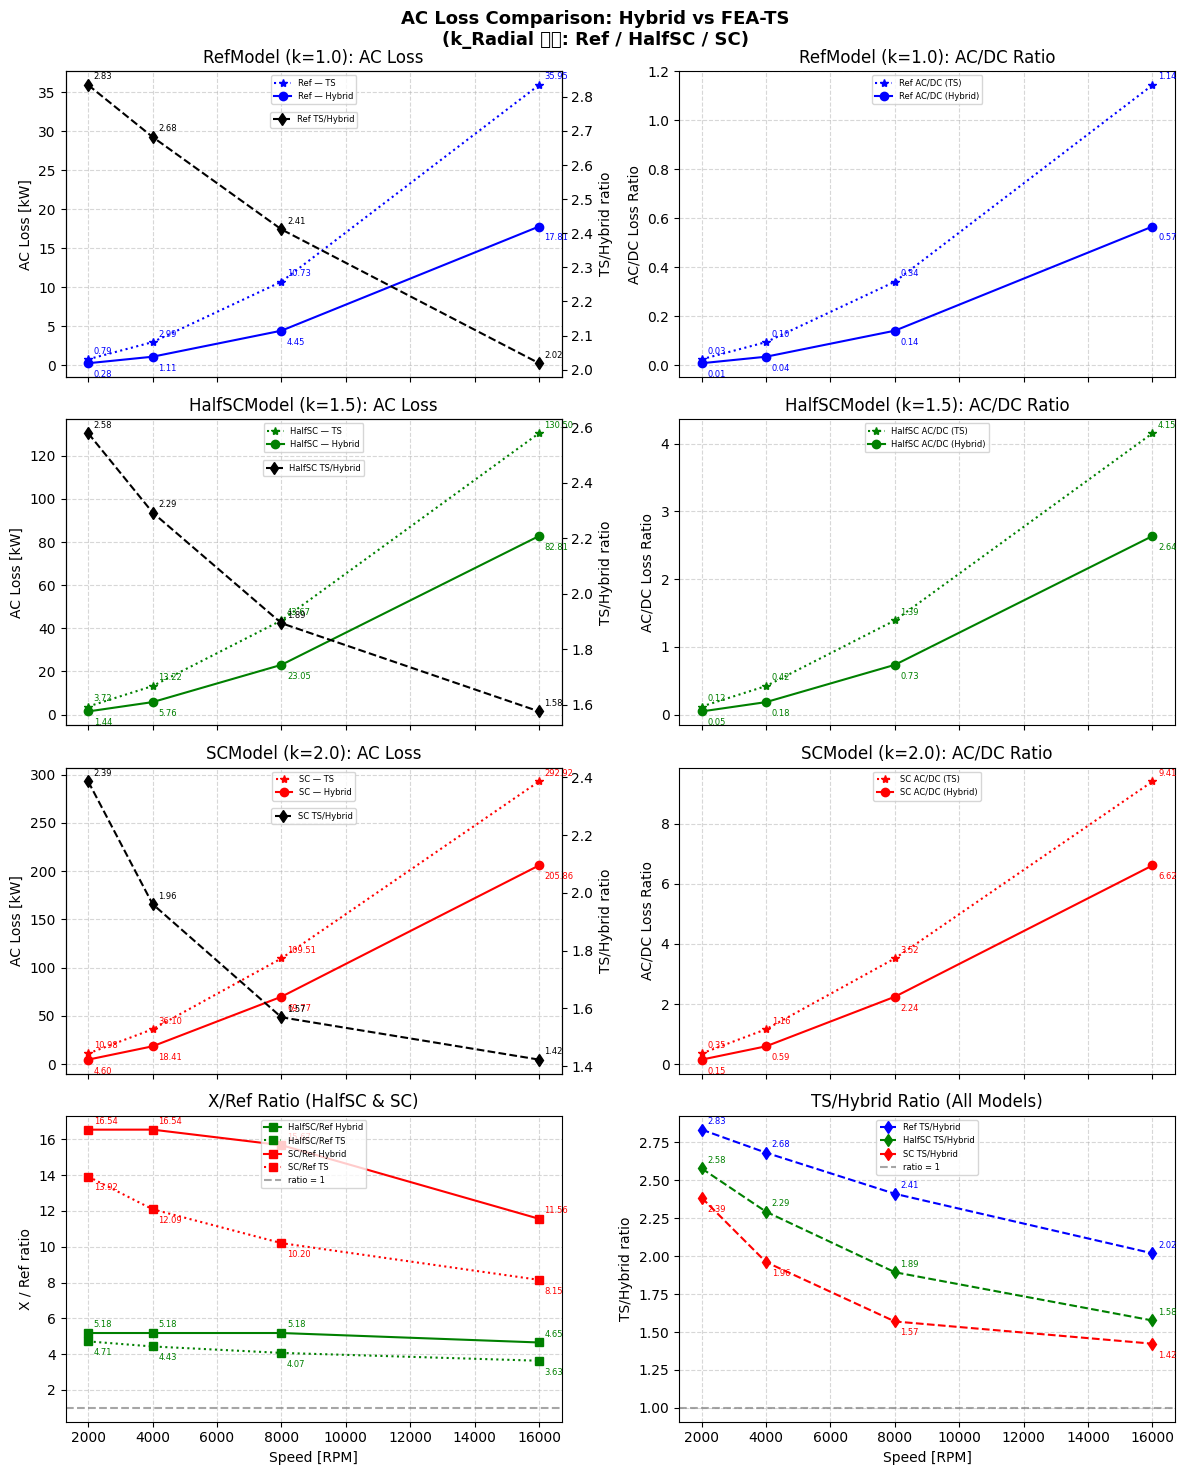

저장 완료: JEET_ACLoss_Comparison_HalfSC.png


In [71]:

def annotate_points(ax, x, y, fmt="{:.2f}", offset=(4, 4), fontsize=6, color="black"):
    """각 데이터 포인트 값을 텍스트로 표시."""
    for xi, yi in zip(x, y):
        ax.annotate(fmt.format(yi), xy=(xi, yi),
                    xytext=offset, textcoords="offset points",
                    fontsize=fontsize, color=color, ha="left")

# ── 비율 계산 ──
ts2hyb_ref = ref_ts_ / ref_hyb
ts2hyb_sc  = sc_ts_  / sc_hyb
ts2hyb_hsc = hsc_ts_ / hsc_hyb

ref_ac_dc_ts  = ref_ts_ / ref_dc
sc_ac_dc_ts   = sc_ts_  / sc_dc
ref_ac_dc_hyb = ref_hyb / ref_dc
sc_ac_dc_hyb  = sc_hyb  / sc_dc

if hsc_dc is not None:
    hsc_ac_dc_ts  = hsc_ts_ / hsc_dc
    hsc_ac_dc_hyb = hsc_hyb / hsc_dc
else:
    hsc_ac_dc_ts  = None
    hsc_ac_dc_hyb = None

sc2ref_hyb  = sc_hyb  / ref_hyb
sc2ref_ts   = sc_ts_  / ref_ts_
hsc2ref_hyb = hsc_hyb / ref_hyb
hsc2ref_ts  = hsc_ts_ / ref_ts_

LEG_KW = dict(fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=1)

# ── Figure 4×2 (행 순서: Ref → HalfSC(k=1.5) → SC(k=2.0) → 비율) ──
fig, axes = plt.subplots(4, 2, figsize=(12, 15), sharex=True)
fig.suptitle("AC Loss Comparison: Hybrid vs FEA-TS\n(k_Radial 순서: Ref / HalfSC / SC)", fontsize=13, fontweight="bold")

# ── [0,0] RefModel: AC Loss (k=1.0) ──
ax = axes[0][0]
ax.plot(speeds, ref_ts_,  ":", marker="*", color="blue", label="Ref — TS")
ax.plot(speeds, ref_hyb,  "-", marker="o", color="blue", label="Ref — Hybrid")
annotate_points(ax, speeds, ref_ts_,  "{:.2f}", color="blue")
annotate_points(ax, speeds, ref_hyb,  "{:.2f}", offset=(4, -10), color="blue")
ax.set_ylabel("AC Loss [kW]"); ax.set_title("RefModel (k=1.0): AC Loss")
ax.legend(**LEG_KW); ax.grid(True, linestyle="--", alpha=0.5)
ax_t = ax.twinx()
ax_t.plot(speeds, ts2hyb_ref, "--", marker="d", color="black", label="Ref TS/Hybrid")
annotate_points(ax_t, speeds, ts2hyb_ref, "{:.2f}", offset=(4, 4), color="black")
ax_t.set_ylabel("TS/Hybrid ratio")
ax_t.legend(fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 0.88))

# ── [0,1] RefModel: AC/DC ratio ──
ax = axes[0][1]
ax.plot(speeds, ref_ac_dc_ts,  ":", marker="*", color="blue", label="Ref AC/DC (TS)")
ax.plot(speeds, ref_ac_dc_hyb, "-", marker="o", color="blue", label="Ref AC/DC (Hybrid)")
annotate_points(ax, speeds, ref_ac_dc_ts,  "{:.2f}", color="blue")
annotate_points(ax, speeds, ref_ac_dc_hyb, "{:.2f}", offset=(4, -10), color="blue")
ax.set_ylabel("AC/DC Loss Ratio"); ax.set_title("RefModel (k=1.0): AC/DC Ratio")
ax.legend(**LEG_KW); ax.grid(True, linestyle="--", alpha=0.5)

# ── [1,0] HalfSCModel: AC Loss (k=1.5) ──
ax = axes[1][0]
ax.plot(speeds, hsc_ts_,  ":", marker="*", color="green", label="HalfSC — TS")
ax.plot(speeds, hsc_hyb,  "-", marker="o", color="green", label="HalfSC — Hybrid")
annotate_points(ax, speeds, hsc_ts_,  "{:.2f}", color="green")
annotate_points(ax, speeds, hsc_hyb,  "{:.2f}", offset=(4, -10), color="green")
ax.set_ylabel("AC Loss [kW]"); ax.set_title("HalfSCModel (k=1.5): AC Loss")
ax.legend(**LEG_KW); ax.grid(True, linestyle="--", alpha=0.5)
ax_t = ax.twinx()
ax_t.plot(speeds, ts2hyb_hsc, "--", marker="d", color="black", label="HalfSC TS/Hybrid")
annotate_points(ax_t, speeds, ts2hyb_hsc, "{:.2f}", offset=(4, 4), color="black")
ax_t.set_ylabel("TS/Hybrid ratio")
ax_t.legend(fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 0.88))

# ── [1,1] HalfSCModel: AC/DC ratio ──
ax = axes[1][1]
if hsc_ac_dc_ts is not None:
    ax.plot(speeds, hsc_ac_dc_ts,  ":", marker="*", color="green", label="HalfSC AC/DC (TS)")
    ax.plot(speeds, hsc_ac_dc_hyb, "-", marker="o", color="green", label="HalfSC AC/DC (Hybrid)")
    annotate_points(ax, speeds, hsc_ac_dc_ts,  "{:.2f}", color="green")
    annotate_points(ax, speeds, hsc_ac_dc_hyb, "{:.2f}", offset=(4, -10), color="green")
else:
    ax.text(0.5, 0.5, "HalfSC DC Loss\nnot available", ha="center", va="center",
            transform=ax.transAxes, fontsize=10, color="gray")
ax.set_ylabel("AC/DC Loss Ratio"); ax.set_title("HalfSCModel (k=1.5): AC/DC Ratio")
ax.legend(**LEG_KW); ax.grid(True, linestyle="--", alpha=0.5)

# ── [2,0] SCModel: AC Loss (k=2.0) ──
ax = axes[2][0]
ax.plot(speeds, sc_ts_,  ":", marker="*", color="red", label="SC — TS")
ax.plot(speeds, sc_hyb,  "-", marker="o", color="red", label="SC — Hybrid")
annotate_points(ax, speeds, sc_ts_,  "{:.2f}", color="red")
annotate_points(ax, speeds, sc_hyb,  "{:.2f}", offset=(4, -10), color="red")
ax.set_ylabel("AC Loss [kW]"); ax.set_title("SCModel (k=2.0): AC Loss")
ax.legend(**LEG_KW); ax.grid(True, linestyle="--", alpha=0.5)
ax_t = ax.twinx()
ax_t.plot(speeds, ts2hyb_sc, "--", marker="d", color="black", label="SC TS/Hybrid")
annotate_points(ax_t, speeds, ts2hyb_sc, "{:.2f}", offset=(4, 4), color="black")
ax_t.set_ylabel("TS/Hybrid ratio")
ax_t.legend(fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 0.88))

# ── [2,1] SCModel: AC/DC ratio ──
ax = axes[2][1]
ax.plot(speeds, sc_ac_dc_ts,  ":", marker="*", color="red", label="SC AC/DC (TS)")
ax.plot(speeds, sc_ac_dc_hyb, "-", marker="o", color="red", label="SC AC/DC (Hybrid)")
annotate_points(ax, speeds, sc_ac_dc_ts,  "{:.2f}", color="red")
annotate_points(ax, speeds, sc_ac_dc_hyb, "{:.2f}", offset=(4, -10), color="red")
ax.set_ylabel("AC/DC Loss Ratio"); ax.set_title("SCModel (k=2.0): AC/DC Ratio")
ax.legend(**LEG_KW); ax.grid(True, linestyle="--", alpha=0.5)

# ── [3,0] X/Ref ratio (SC & HalfSC) ──
ax = axes[3][0]
ax.plot(speeds, hsc2ref_hyb, "-", marker="s", color="green", label="HalfSC/Ref Hybrid")
ax.plot(speeds, hsc2ref_ts,  ":", marker="s", color="green", label="HalfSC/Ref TS")
ax.plot(speeds, sc2ref_hyb,  "-", marker="s", color="red",   label="SC/Ref Hybrid")
ax.plot(speeds, sc2ref_ts,   ":", marker="s", color="red",   label="SC/Ref TS")
annotate_points(ax, speeds, hsc2ref_hyb, "{:.2f}", offset=(4, 4),   color="green")
annotate_points(ax, speeds, hsc2ref_ts,  "{:.2f}", offset=(4, -10), color="green")
annotate_points(ax, speeds, sc2ref_hyb,  "{:.2f}", color="red")
annotate_points(ax, speeds, sc2ref_ts,   "{:.2f}", offset=(4, -10), color="red")
ax.axhline(1.0, linestyle="--", color="gray", alpha=0.7, label="ratio = 1")
ax.set_xlabel("Speed [RPM]"); ax.set_ylabel("X / Ref ratio")
ax.set_title("X/Ref Ratio (HalfSC & SC)")
ax.legend(**LEG_KW); ax.grid(True, linestyle="--", alpha=0.5)

# ── [3,1] TS/Hybrid ratio — All models ──
ax = axes[3][1]
ax.plot(speeds, ts2hyb_ref, "--", marker="d", color="blue",  label="Ref TS/Hybrid")
ax.plot(speeds, ts2hyb_hsc, "--", marker="d", color="green", label="HalfSC TS/Hybrid")
ax.plot(speeds, ts2hyb_sc,  "--", marker="d", color="red",   label="SC TS/Hybrid")
annotate_points(ax, speeds, ts2hyb_ref, "{:.2f}", color="blue")
annotate_points(ax, speeds, ts2hyb_hsc, "{:.2f}", offset=(4, 4),   color="green")
annotate_points(ax, speeds, ts2hyb_sc,  "{:.2f}", offset=(4, -10), color="red")
ax.axhline(1.0, linestyle="--", color="gray", alpha=0.7, label="ratio = 1")
ax.set_xlabel("Speed [RPM]"); ax.set_ylabel("TS/Hybrid ratio")
ax.set_title("TS/Hybrid Ratio (All Models)")
ax.legend(**LEG_KW); ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
out_path = "JEET_ACLoss_Comparison_HalfSC.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"저장 완료: {out_path}")


In [47]:
1.5**4

5.0625

# Motor-CAD Hybrid AC Loss Code Notebook

▶ [pyMotorCAD_Hybrid_AClossCode.ipynb](./pyMotorCAD_Hybrid_AClossCode.ipynb)